In [1]:
# Load in packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

In [2]:
path = "/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_first_order_SHAP_analysis/outputs/dpsi_vs_local_SHAP/all_partitions/dpsi_vs_local_SHAP_scatterplot_data_all_partitions.tsv.gz"

In [3]:
table = pd.read_csv(path, sep='\t', compression='gzip')

In [4]:
# Set significance threshold

# Create sig_df with significant events
sig_df = table[
    (table['dPSI'].abs() >= 0.05) & 
    (table['rMATS FDR'] <= 0.1)
].copy()

In [5]:
# Drop rows where dSHAP = 0

df = sig_df[sig_df["CTRL - KD Local SHAP"] != 0]

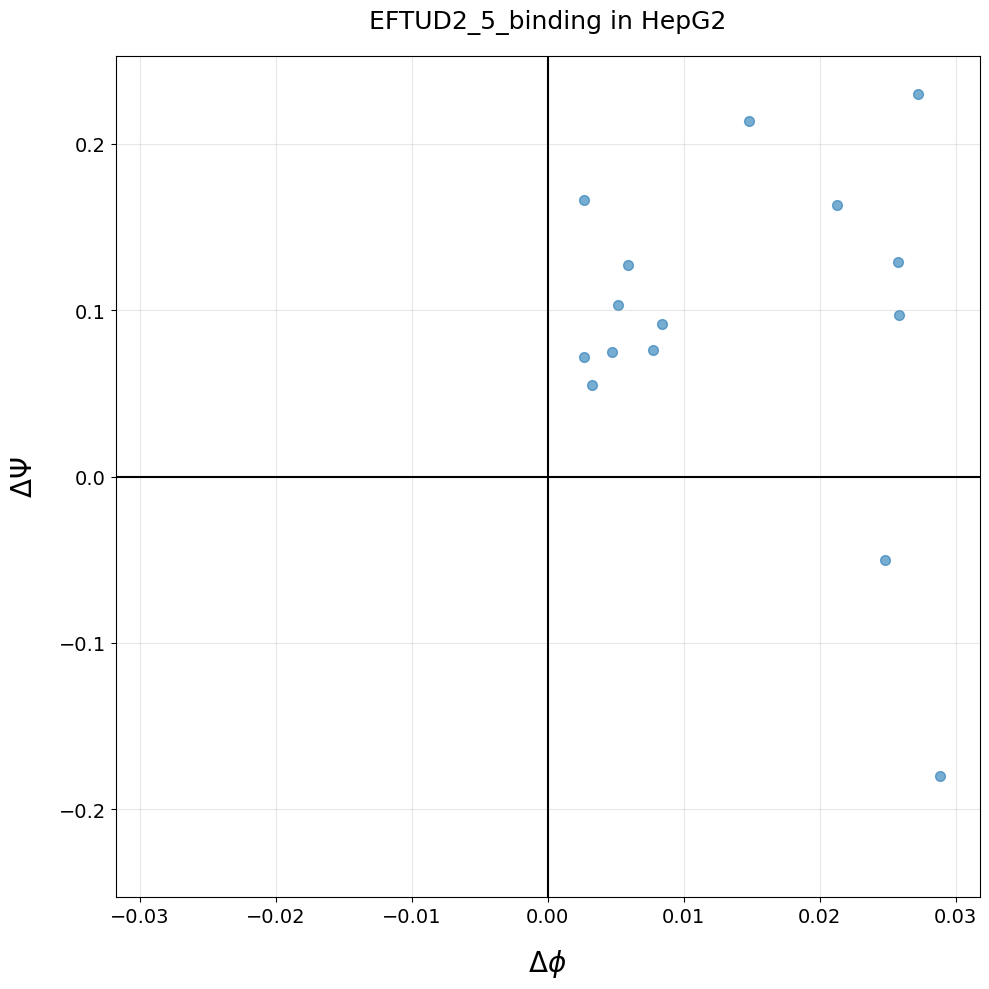

In [6]:
# Scatterplots for the more relaxed significance threshold (dPSI > 0.05, FDR < 0.1)

def make_one_positon_plot(data, feature, cell_line):

    # Filter the dataframe
    plot_df = df[(df["Feature"] == "EFTUD2_5_binding") & (df["Cell Line"] == "HepG2")]
    
    # Create the scatter plot
    fig, ax = plt.subplots(figsize=(10, 10))
    
    ax.scatter(plot_df["CTRL - KD Local SHAP"], plot_df["dPSI"], alpha=0.6, s=50)
    
    # Add quadrant lines at x=0 and y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
    
    # Center the axes to show all 4 quadrants
    x_max = max(abs(plot_df["CTRL - KD Local SHAP"].min()), abs(plot_df["CTRL - KD Local SHAP"].max()))
    y_max = max(abs(plot_df["dPSI"].min()), abs(plot_df["dPSI"].max()))
    
    ax.set_xlim(-x_max * 1.1, x_max * 1.1)
    ax.set_ylim(-y_max * 1.1, y_max * 1.1)
    
    # Labels with Greek symbols and title with increased font size and padding
    ax.set_xlabel(r"$\Delta\phi$", fontsize=20, labelpad=15)
    ax.set_ylabel(r"$\Delta\Psi$", fontsize=20, labelpad=15)
    ax.set_title("EFTUD2_5_binding in HepG2", fontsize=18, pad=20)
    
    # Increase tick label font size
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    # Add grid
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [19]:
def make_layered_scatterplot(list, cell_line):
    # Create the scatter plot
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Define colors for each feature
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    # Plot each feature with a different color
    for i, each in enumerate(list):
        plot_df = sig_df[(sig_df["Feature"] == each) & (sig_df["Cell Line"] == cell_line)]
        ax.scatter(plot_df["CTRL - KD Local SHAP"], plot_df["dPSI"], 
                   alpha=0.6, s=50, color=colors[i], label=each)
    
    # Add quadrant lines at x=0 and y=0 (OUTSIDE the loop)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
    
    # Center the axes to show all 4 quadrants (OUTSIDE the loop)
    all_x = sig_df[(sig_df["Feature"].isin(list)) & (sig_df["Cell Line"] == cell_line)]["CTRL - KD Local SHAP"]
    all_y = sig_df[(sig_df["Feature"].isin(list)) & (sig_df["Cell Line"] == cell_line)]["dPSI"]
    
    x_max = max(abs(all_x.min()), abs(all_x.max()))
    y_max = max(abs(all_y.min()), abs(all_y.max()))
    
    ax.set_xlim(-x_max * 1.1, x_max * 1.1)
    ax.set_ylim(-y_max * 1.1, y_max * 1.1)
    
    # Labels with Greek symbols and title with increased font size and padding
    ax.set_xlabel(r"$\Delta\phi$", fontsize=20, labelpad=15)
    ax.set_ylabel(r"$\Delta\Psi$", fontsize=20, labelpad=15)
    ax.set_title(f"Candidate Features in {cell_line}", fontsize=18, pad=20)
    
    # Increase tick label font size
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    # Add grid
    ax.grid(True, alpha=0.3)
    
    # Add legend
    ax.legend(fontsize=12, loc='best', framealpha=0.9)
    
    plt.tight_layout()
    plt.show()